# Text Mining and Natural Language Processing Tutorial

Text Mining and Natural Language Processing (NLP) are powerful techniques used to analyze, process, and derive meaningful insights from textual data. This tutorial covers the basics of text preprocessing, feature extraction, text representation, and applying NLP techniques for sentiment analysis and text classification.

## Objective(s):
Upon completion of this lab session, learners will be able to:
* Analyze and Preprocess Textual Data.
* Extract Relevant Features from the Text.
* Train, and Evaluate ML Model on the Text data.
* Make Predictions of the Trained Model on Unseen User Input.

## 1. Dataset
For this tutorial, we’ll use the [IMDb Dataset](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews) for binary sentiment classification (positive or negative). It contains movie reviews labeled as positive or negative.

In [7]:
# import Libraries
import nltk
import random
import string
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import BernoulliNB
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /home/vscode/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/vscode/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/vscode/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/vscode/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
data = pd.read_csv("./data/imdb-dataset-of-50k-movie-reviews.zip")
print(data.head(5))

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [9]:
print(data.columns)

Index(['review', 'sentiment'], dtype='object')


In [10]:
print(data["sentiment"].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


## 2. Text Preprocessing
Text preprocessing involves cleaning the text to make it suitable for machine learning algorithms.

### Steps in Preprocessing:
1. **Lowercasing:** Convert all text to lowercase.
2. **Remove Punctuation:** Remove special characters and punctuation marks.
3. **Remove Stopwords:** Eliminate commonly used words that carry little meaning.
4. **Tokenization:** Split text into individual words (tokens).
5. **Stemming/Lemmatization:** Reduce words to their root form.

In [11]:
def remove_emojis(text):
    """
    Remove emojis from the given text.
    """
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # Emoticons
        u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # Transport & map symbols
        u"\U0001F700-\U0001F77F"  # Alchemical symbols
        u"\U0001F780-\U0001F7FF"  # Geometric shapes extended
        u"\U0001F800-\U0001F8FF"  # Supplemental arrows-C
        u"\U0001F900-\U0001F9FF"  # Supplemental symbols & pictographs
        u"\U0001FA00-\U0001FA6F"  # Chess symbols
        u"\U0001FA70-\U0001FAFF"  # Symbols and pictographs extended-A
        u"\U00002702-\U000027B0"  # Dingbats
        u"\U000024C2-\U0001F251"  # Enclosed characters
        "]+",
        flags=re.UNICODE,
    )
    return emoji_pattern.sub(r'', text)

In [12]:
def preprocess_text(text):
    """
    Perform preprocessing steps on a given text.
    """
    # Lowercase the text
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove emojis
    text = remove_emojis(text)
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize the text
    tokens = nltk.word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    # Lemmatize tokens
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    # Rejoin tokens into a single string
    return ' '.join(tokens)

### How This Works
#### 1. Remove URLs:
* Uses a regex pattern (http\S+|www\S+) to identify and eliminate all URLs.
#### 2. Remove Emojis:
* Matches Unicode ranges corresponding to emojis and substitutes them with an empty string.
#### 3. Lowercasing, Tokenization, and Lemmatization:
* These steps ensure uniformity and reduce words to their base form for better model training.
#### 4. Stopword Removal:
* Removes commonly used words that add little value to the sentiment analysis task.

### Example Usage

In [13]:
sample_text = "Check out this amazing movie review! 😍🎥 https://example.com"
processed_text = preprocess_text(sample_text)
print("Original Text: ", sample_text)
print("Processed Text: ", processed_text)

Original Text:  Check out this amazing movie review! 😍🎥 https://example.com
Processed Text:  check amazing movie review


In [14]:
cleaned_data = data.copy()
cleaned_data['review'] = cleaned_data['review'].apply(preprocess_text)
print("cleaned dataset")
print("=================")
print(cleaned_data.head(10))

cleaned dataset
                                              review sentiment
0  one reviewer mentioned watching oz episode you...  positive
1  wonderful little production br br filming tech...  positive
2  thought wonderful way spend time hot summer we...  positive
3  basically there family little boy jake think t...  negative
4  petter matteis love time money visually stunni...  positive
5  probably alltime favorite movie story selfless...  positive
6  sure would like see resurrection dated seahunt...  positive
7  show amazing fresh innovative idea first aired...  negative
8  encouraged positive comment film looking forwa...  negative
9  like original gut wrenching laughter like movi...  positive


## 3. Data Visualization

### 3.1 Word Frequency Plot
Visualize the most frequent words in positive and negative reviews.

In [15]:
from collections import Counter

def plot_word_frequency(reviews, label, top_n=20):
    """
    Plot the most frequent words for a given label.
    """
    # Combine all reviews for the given label
    combined_text = ' '.join(reviews)
    # Tokenize
    words = combined_text.split()
    # Get word frequency
    word_freq = Counter(words).most_common(top_n)
    words, frequencies = zip(*word_freq)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(words, frequencies, color='skyblue')
    plt.title(f"Top {top_n} Words in {label} Reviews")
    plt.xticks(rotation=45)
    plt.show()

Top words in positive reviews:


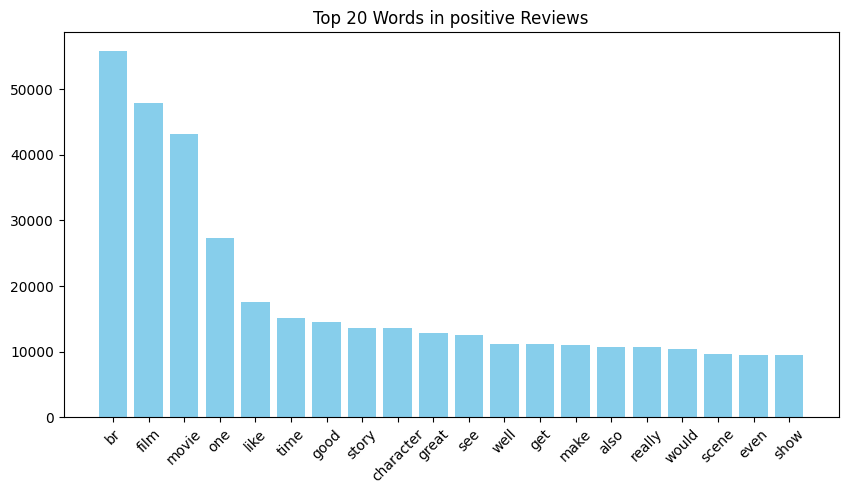

Top words in negative reviews:


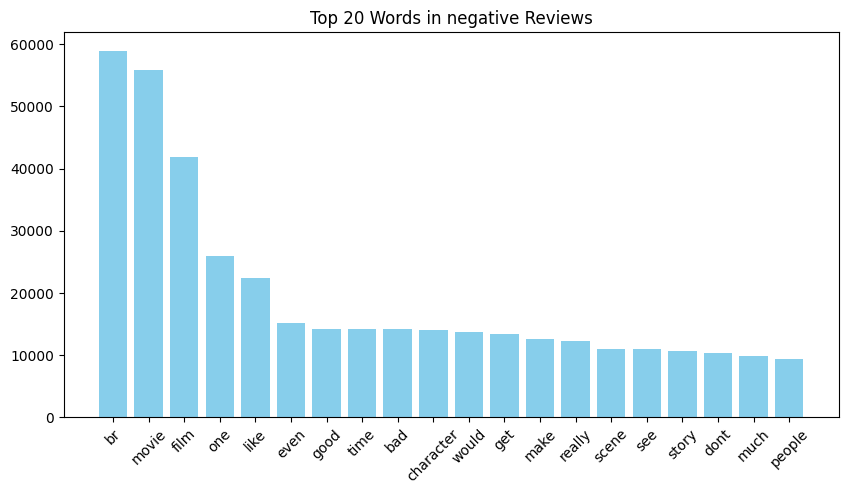

In [16]:
# Step 3: Separate Reviews by Sentiment
positive_reviews = cleaned_data[cleaned_data['sentiment'] == 'positive']['review']
negative_reviews = cleaned_data[cleaned_data['sentiment'] == 'negative']['review']

# Step 4: Plot Word Frequencies
# Positive Reviews
print("Top words in positive reviews:")
plot_word_frequency(positive_reviews, label="positive")

# Negative Reviews
print("Top words in negative reviews:")
plot_word_frequency(negative_reviews, label="negative")

### 3.2 Word Cloud
Generate a word cloud for given set of reviews.

In [17]:
# Generate WordCloud for Positive and Negative Reviews
def generate_wordcloud(reviews, label):
    """
    Generate a word cloud for a given set of reviews.
    """
    combined_text = ' '.join(reviews)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(combined_text)
    
    # Plot the WordCloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {label} Reviews", fontsize=16)
    plt.show()


Word Cloud for Positive Reviews:


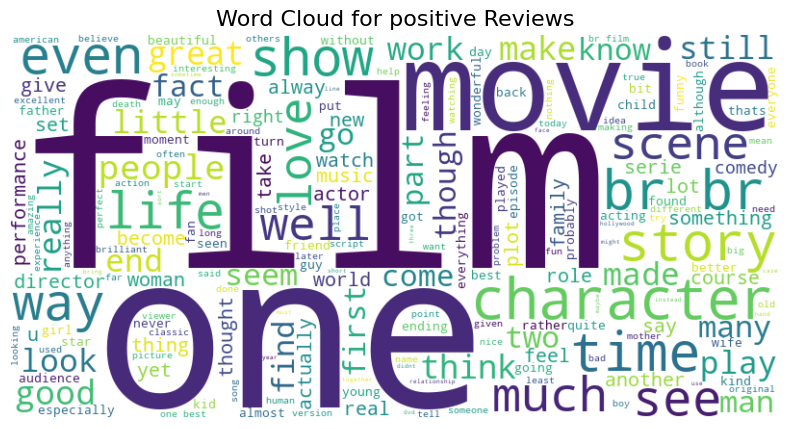

Word Cloud for Negative Reviews:


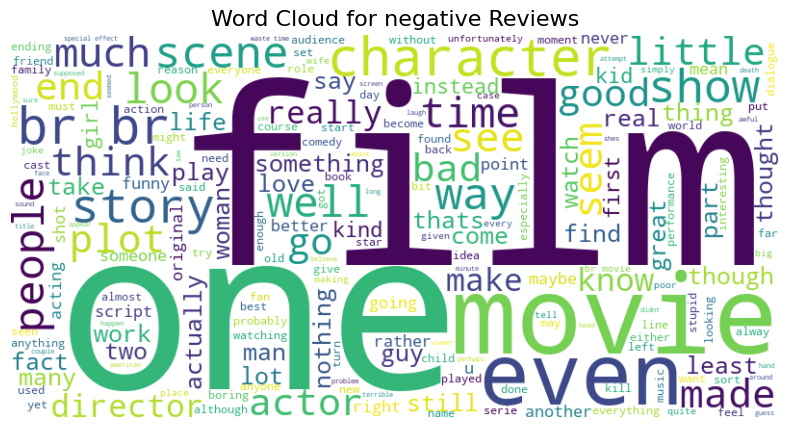

In [18]:
# WordCloud for Positive Reviews
print("Word Cloud for Positive Reviews:")
generate_wordcloud(positive_reviews, label="positive")

# WordCloud for Negative Reviews
print("Word Cloud for Negative Reviews:")
generate_wordcloud(negative_reviews, label="negative")

## 4. Label Encoding

In [19]:
# Label Encoding the output
encoder = LabelEncoder()
cleaned_data["sentiment"] = encoder.fit_transform(cleaned_data["sentiment"])
print("Encoded dataset")
print("================")
print(cleaned_data.head(10))

Encoded dataset
                                              review  sentiment
0  one reviewer mentioned watching oz episode you...          1
1  wonderful little production br br filming tech...          1
2  thought wonderful way spend time hot summer we...          1
3  basically there family little boy jake think t...          0
4  petter matteis love time money visually stunni...          1
5  probably alltime favorite movie story selfless...          1
6  sure would like see resurrection dated seahunt...          1
7  show amazing fresh innovative idea first aired...          0
8  encouraged positive comment film looking forwa...          0
9  like original gut wrenching laughter like movi...          1


In [20]:
# split data into input feature and labels
x = cleaned_data['review']
y = cleaned_data['sentiment']

## 5. Feature Extraction
Feature extraction converts text data into numerical representations.

### a. Bag of Words (BoW)
BoW counts the frequency of each word in the text.

In [21]:
def bow_feature_extraction(reviews):
    vectorizer = CountVectorizer()
    features = vectorizer.fit_transform(reviews)
    return features, vectorizer

In [22]:
bow_features, bow_vectorizer = bow_feature_extraction(x)
print(bow_features)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4876115 stored elements and shape (50000, 164505)>
  Coords	Values
  (0, 102716)	1
  (0, 120850)	1
  (0, 90341)	1
  (0, 157829)	2
  (0, 105378)	5
  (0, 45574)	2
  (0, 163442)	1
  (0, 67224)	1
  (0, 121452)	2
  (0, 46973)	1
  (0, 62990)	1
  (0, 89556)	1
  (0, 17270)	3
  (0, 51852)	2
  (0, 145446)	1
  (0, 139319)	2
  (0, 18663)	1
  (0, 152532)	1
  (0, 125729)	1
  (0, 156109)	4
  (0, 128980)	1
  (0, 161478)	1
  (0, 58563)	2
  (0, 149944)	1
  (0, 130888)	4
  :	:
  (49999, 125250)	1
  (49999, 78638)	1
  (49999, 152580)	1
  (49999, 81364)	1
  (49999, 72245)	1
  (49999, 47620)	1
  (49999, 9443)	1
  (49999, 63196)	1
  (49999, 70661)	1
  (49999, 70211)	1
  (49999, 7732)	1
  (49999, 149238)	1
  (49999, 78154)	1
  (49999, 136330)	1
  (49999, 89018)	1
  (49999, 119749)	1
  (49999, 20120)	1
  (49999, 98820)	1
  (49999, 23325)	1
  (49999, 47657)	1
  (49999, 59302)	1
  (49999, 119731)	1
  (49999, 95525)	1
  (49999, 31911)	1
  (49999, 163365)

### b. Term Frequency-Inverse Document Frequency (TF-IDF)
TF-IDF stands for :
* **Term frequency:** How often a word appears in a document
* **Inverse document frequency:** How important a term is, which is adjusted for how many documents contain the word

In [23]:
def tfidf_feature_extraction(reviews):
    vectorizer = TfidfVectorizer()
    features = vectorizer.fit_transform(reviews)
    return features, vectorizer

In [24]:
tfidf_features, tfidf_vectorizer = tfidf_feature_extraction(x)
print(tfidf_features)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4876115 stored elements and shape (50000, 164505)>
  Coords	Values
  (0, 102716)	0.018252629733148555
  (0, 120850)	0.058811625817413234
  (0, 90341)	0.05749125933555252
  (0, 157829)	0.06743476074821471
  (0, 105378)	0.3883197738271453
  (0, 45574)	0.09266965095006685
  (0, 163442)	0.04748931967002604
  (0, 67224)	0.072657527942223
  (0, 121452)	0.07448513410870075
  (0, 46973)	0.050257059547594046
  (0, 62990)	0.050354108132129295
  (0, 89556)	0.06669916230440491
  (0, 17270)	0.05364975391605547
  (0, 51852)	0.05577320622159922
  (0, 145446)	0.028328802272963576
  (0, 139319)	0.1455818944797256
  (0, 18663)	0.08094176751150038
  (0, 152532)	0.09715430271352973
  (0, 125729)	0.027396359335573814
  (0, 156109)	0.20597240877490844
  (0, 128980)	0.03813212276593966
  (0, 161478)	0.04393358115586924
  (0, 58563)	0.0585511285080221
  (0, 149944)	0.06348005673726242
  (0, 130888)	0.12576974627335202
  :	:
  (49999, 125250)	0.1061

In [25]:
x_train, x_test, y_train, y_test = train_test_split(bow_features, y, test_size = 0.2, random_state = 42, shuffle = True)

print("X train Shape: ",x_train.shape)
print ("X Test Shape: ",x_test.shape)
print("Y train Shape: ",y_train.shape)
print("Y Test Shape: ",y_test.shape)

X train Shape:  (40000, 164505)
X Test Shape:  (10000, 164505)
Y train Shape:  (40000,)
Y Test Shape:  (10000,)


## 6. Train Model

In [26]:
model = LogisticRegression()
model.fit(x_train,y_train)
print(model)

LogisticRegression()


/workspaces/ml_labs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
pred = model.predict(x_test)
acc = accuracy_score(y_test,pred)
print("Test Accuracy: ",np.round(acc,2))

Test Accuracy:  0.89


In [28]:
# Display Classification Report
class_names = ['Negative', 'Positive']
print(classification_report(y_test, pred, target_names = class_names, digits = 4 ))

              precision    recall  f1-score   support

    Negative     0.8912    0.8752    0.8831      4961
    Positive     0.8793    0.8948    0.8870      5039

    accuracy                         0.8851     10000
   macro avg     0.8853    0.8850    0.8851     10000
weighted avg     0.8852    0.8851    0.8851     10000



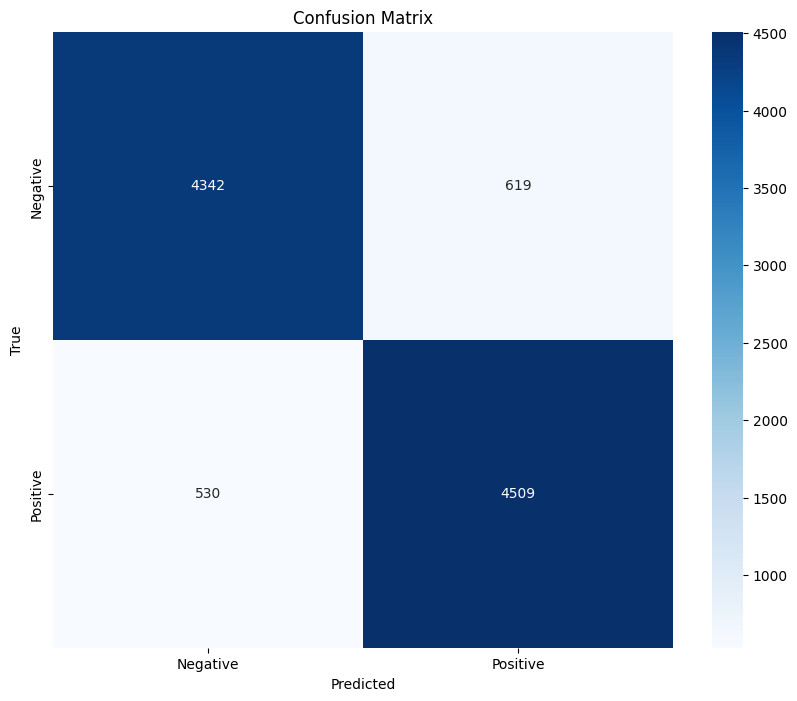

In [29]:
# Plot confusion matrix
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(10, 8))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [30]:
import pickle
# Save the Model in a Pkl File
pickle.dump(model, open('linear_regression.pkl', 'wb'))

## 7. Application Phase

In [31]:
input_text = input("\nEnter a Movie Review: ")

In [32]:
def predict_sentiment(model, vectorizer, input_text):
    """
    Predict sentiment for new user input.
    """
    # Preprocess the input text
    processed_text = preprocess_text(input_text)
    # Transform the text using the vectorizer
    transformed_text = vectorizer.transform([processed_text])
    # Predict
    sentiment = model.predict(transformed_text)
    return "Positive" if sentiment[0] == 1 else "Negative"

In [35]:
pred = predict_sentiment(model,bow_vectorizer,input_text)
print("Sentiment = ",pred)

Sentiment =  Positive
